In [1]:
import numpy as np

import ngsolve 
from ngsolve.webgui import Draw
import netgen.geom2d

import matplotlib.pyplot as plt
import matplotlib.tri as tri
import copy
import importlib
import pickle
%matplotlib inline

notebookroot = 'Rec_v002'  # for output file names

import bio_mem_helpers   # helper routines


In [64]:
importlib.reload(bio_mem_helpers)  # if you are working on the helper routines 

<module 'bio_mem_helpers' from '/Users/aquillen/Desktop/summer25/pylab/bio_fem2/bio_mem_helpers.py'>

In [62]:
# parameters for this run 

mu = 1.0; lam = 20; pi_k = 0.1;  dt = 0.04  # shear modulus, Lame parm, damping parm, timestep
p0=0.5; AA = 3.0;  # parameters for non-linear op

tend= 80.0; scount = int(0.5/dt) # scount is frequency of outputs and redraws, tend is final time of integration 

parmlabel = ""
parmlabel += r'$A$={:.0f}'.format(AA)
parmlabel +=','
parmlabel += r'$\pi_k$={:.1f}'.format(pi_k)
parmlabel +=','
parmlabel += r'$\pi_\lambda$={:.0f}'.format(lam)
parmlabel +=','
parmlabel += r'$p_*$={:.1f}'.format(p0)
#parmlabel += ',N'
print(parmlabel)

sim_parms = bio_mem_helpers.sim_stuff(mu,lam,pi_k,dt,p0,AA,scount,parmlabel)

$A$=3,$\pi_k$=0.1,$\pi_\lambda$=20,$p_*$=0.5


### Trying more oscillators 

In [43]:
# generate a 2d triangular mesh in a shaped domain
# https://docu.ngsolve.org/latest/i-tutorials/unit-4.1.2-csg2d/csg2d.html
# run this even if you have saved the run, we need the mesh  
geo = netgen.geom2d.CSG2d()

fac = 10  # rescaling factor 
yratio = 0.6

# make rectangle
dx = fac
dy = fac * yratio
rect1 = netgen.geom2d.Rectangle(pmin=(-dx,-dy), pmax=(dx,dy), bottom = "b_boundary", \
                                top = "t_boundary", right="r_boundary", left="l_boundary")

all_boundaries = 'r_boundary|b_boundary|t_boundary|l_boundary'
d_boundaries = 't_boundary|b_boundary' # dirichlet boundaries 
n_boundaries = 'l_boundary|r_boundary'  # Neumann boundaries 

geo.Add(rect1)

# generate the mesh
maxh_mesh = 0.04*fac  # max distance between nodes?
mesh = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh))  # maxh here sets the scale of elements 
print(f"vertices={mesh.nv}, edges ={mesh.ne}")  # print numbers of vertices and edges!

# create finite element system 'fes'  only for displacement field u
korder = 3  # note!!!!
Q1 = ngsolve.VectorH1(mesh, order=korder,dirichlet=d_boundaries) 
# Choose an element that is in the Sobolev space H1, first 2d field
fes = Q1   # our finite element space is  a 2d vector space 

Draw(mesh) # show the mesh

print(mesh.GetBoundaries())
#help(netgen.geom2d.Circle)
#help(netgen.geom2d.SplineGeometry)
#help(netgen.geom2d.Rectangle)
print(fac,fac*yratio)

vertices=1806, edges =3450


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

('b_boundary', 'r_boundary', 't_boundary', 'l_boundary')
10 6.0


In [18]:
# finally we get to run stuff!

# read in the parameters from the parameter list
mu, lam, pi_k, dt, p0, AA, scount, parmlabel = sim_parms.ret_info()

# lam is actually lambda/mu = (B-mu)/mu
#mu = 1.0; lam = 20; pi_k = 0.1;  dt = 0.04  # shear modulus, Lame parm, damping parm, timestep
sp_fun,f,invm,a,invastar = bio_mem_helpers.mkops_u(fes,mu,lam,pi_k,dt)  # create linear and bilinear forms

if (1==1):  # comment out if you are adding to a saved run 

    sig=0.1;  alpha=0.1  # for initial conditions, parms control noises, 
    # noise is set to be weaker in p
    # if div0=False then  p(k) propto k^-alpha   if alpha small then is white noise 
    gfu = bio_mem_helpers.mkinit_pink(fes,sig,alpha,div0=False)  # make initial conditions for u, p
    gfp = bio_mem_helpers.mkinit_pink(fes,sig/100,alpha,div0=False)  # make initial conditions for u, p

    gfu_vel = ngsolve.GridFunction(fes)  # place holder for velocity field 
    gfu_vel.Set((0.0,0.0))
    gfu_list=[]; gfp_list=[]; gfv_list=[]

    
# two scenes showing vector fields, first displacement field 
scene = Draw(gfu,mesh, settings = {  \
    "Colormap" : { "ncolors" : 20 },"Objects" : {"Wireframe" : False, "Vectors" : True, "Surface" : False} , \
    "Vectors"  : {"grid_size" :50} });  # 

#p0=0.5; AA = 3.0;  # parameters for non-linear op
tend= 80.0; # scount = int(0.5/dt) # scount is frequency of outputs and redraws, tend is final time of integration 

# run the simulation! gfu_list will store a bunch of velocity grid functions
gfu_list,gfp_list,gfv_list = bio_mem_helpers.time_stepping(fes,gfu,gfp,gfu_vel,sp_fun,f,invm,a,invastar,dt,AA,p0,scene,\
                                           t0=0,tend=tend,scount=scount,gfu_list=gfu_list,gfp_list=gfp_list,gfv_list=gfv_list)
timevec =  bio_mem_helpers.mktimevec(len(gfu_list),scount,dt)

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Colormap': {'ncolors': 20}, …

 79.9600000000013945

In [ ]:
# we can add onto it and integrate longer if we want to
tend = 220
gfu_list,gfp_list,gfv_list = bio_mem_helpers.time_stepping(fes,gfu,gfp,gfu_vel,sp_fun,f,invm,a,invastar,dt,AA,p0,scene,\
                         t0=0,tend=tend,scount=scount,gfu_list=gfu_list,gfp_list=gfp_list,gfv_list=gfv_list)

timevec =  bio_mem_helpers.mktimevec(len(gfu_list),scount,dt)
print(' ',np.max(timevec))

In [63]:
# save the run so we don't need to rerun the simulation!

# see https://docu.ngsolve.org/latest/i-tutorials/appendix-pickling/pickling.html
save_data = 1  # was saved 
if (save_data ==1):
    ofilename = notebookroot + "gfus.pkl"
    outfile = open(ofilename, "wb")
    print(ofilename)
    pickle.dump([gfu_list,gfp_list,gfv_list,gfu,gfp,gfu_vel,sim_parms], outfile)
    print(len(gfu_list))
    outfile.close()

Rec_v002gfus.pkl
626


In [47]:
# if you have already saved the simulation, then read it back in here!
load_data = 1 
if (load_data ==1):
    ofilename = notebookroot + "gfus.pkl"
    infile = open(ofilename, "rb")
    print(ofilename)
    [gfu_list,gfp_list,gfv_list,gfu,gfp,gfu_vel,sim_parms] =  pickle.load(infile)
    print(len(gfu_list))
    timevec =  bio_mem_helpers.mktimevec(len(gfu_list),scount,dt)
    mu,lam,pi_k,dt,p0,AA,scount,parmlabel = sim_parms.ret_info()  # restore simulation parameters!
    infile.close()
    

Rec_v002gfus.pkl
626


In [23]:
coarsemesh = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh*2))  # maxh here sets the scale of elements 
if (1==0):
    du = ngsolve.div(gfu)  # if you want to look at divergence (small but non-zero)
    Draw(du,mesh)

In [ ]:
klist = [300,310,320,333]  # here plotting vorticity and velocity vectors 
#klist = np.arange(588,624,1)  # mins at 588 605 and 623
if (1==1):# test so you can adjust the images , and plot a bunch of outouts 

    for k in klist:
        root =  notebookroot+'_tryvel_'
        ofile = bio_mem_helpers.mkpngname(root,k)
        
        time = timevec[k]
        time_label = 't={:.1f}'.format(time)

        pl = parmlabel
        if k >105:
            pl = ''

        bio_mem_helpers.vorplot(gfv_list[k],mesh,coarsemesh,dt,time_label,ofile,vecscale=0.8,vlength_set=1,\
                            parmlabel=pl,cbar_shrink=0.80,cbar_label='vorticity',figy=0.6,vmaxx=0.7,qkeyloc=1)
              
    plt.close('all')  # there is a full period here

In [8]:
plt.close('all')

Rec_v002_trydisp300.png


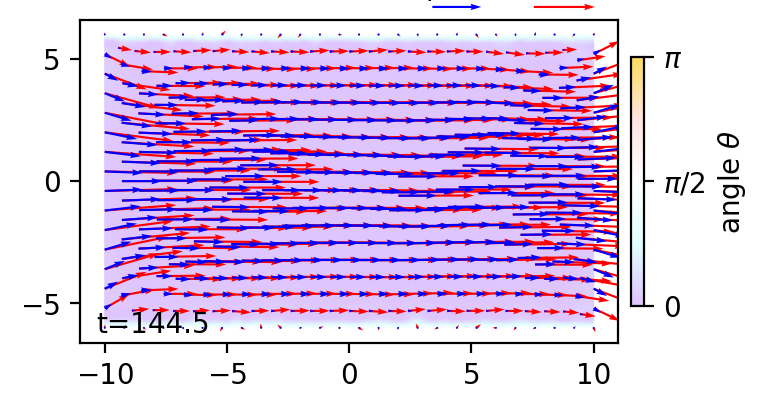

Rec_v002_trydisp310.png


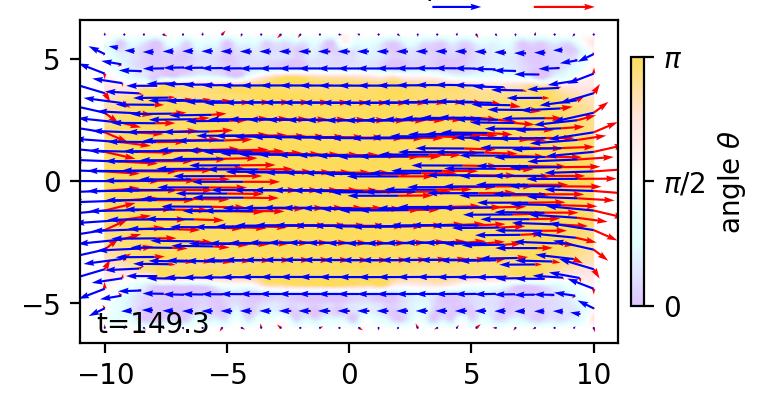

Rec_v002_trydisp593.png


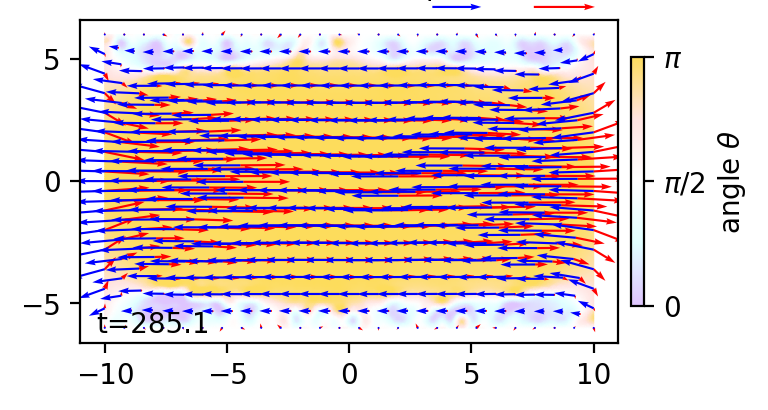

In [30]:
# show displacement and polarization vectors together 
#importlib.reload(bio_mem_helpers) 

klist = [300,310,593]
if (1==1):# not a test
    root =  notebookroot+'_trydisp'
    for k in klist:
        ofile = bio_mem_helpers.mkpngname(root,k)
        #print(ofile)
        time = timevec[k]
        tlabel = 't={:.1f}'.format(time)
        pl = ''
        if (k < 105):
            pl = parmlabel
        bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_dotprod=True,\
            vecscale_u=0.8, vlength_set_u = 2, vecscale_p = 0.5,vlength_set_p = 1,yratio=0.7,cbar_shrink=0.5, \
                                    parmlabel=pl,cbar_label=r'angle $\theta$',qkeyloc=1)


Rec_v002_trycross591.png


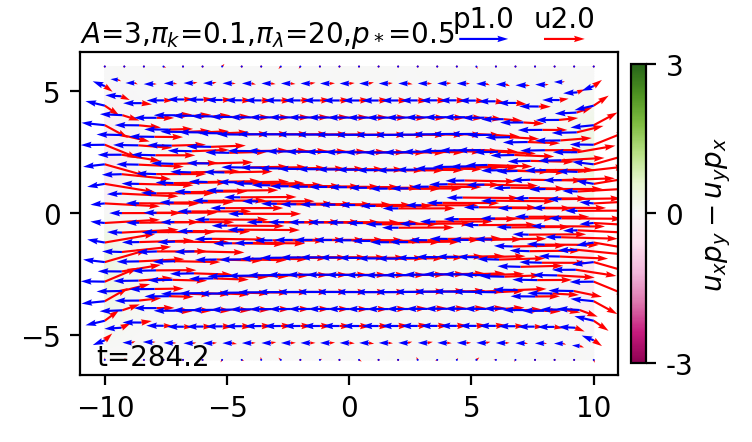

Rec_v002_trycross593.png


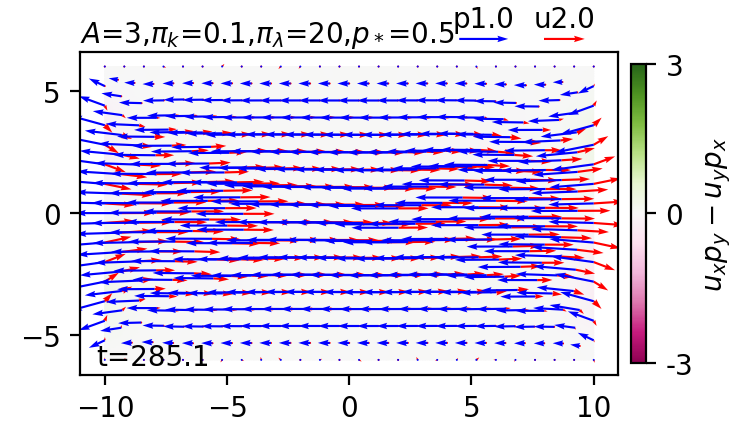

Rec_v002_trycross600.png


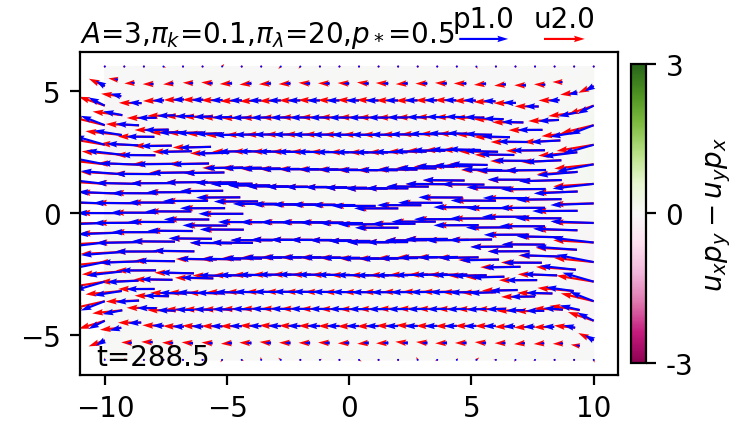

Rec_v002_trycross602.png


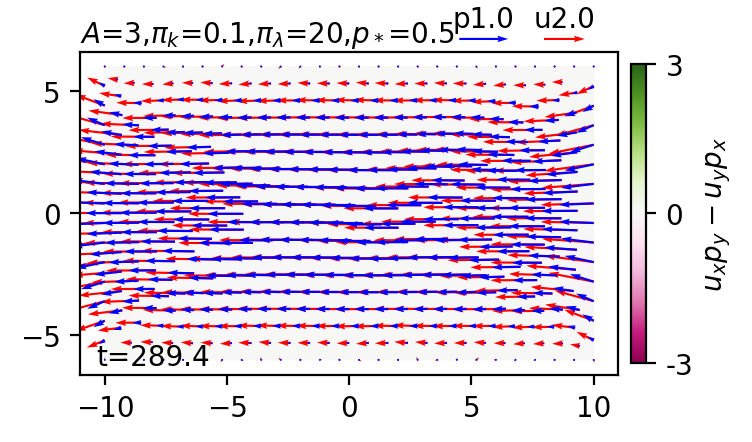

Rec_v002_trycross606.png


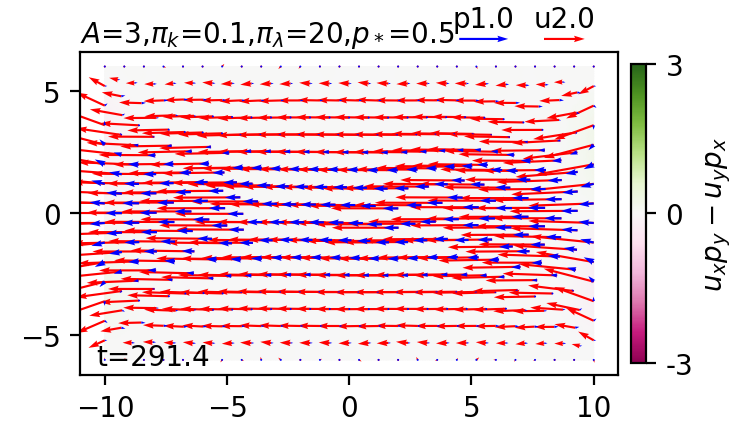

Rec_v002_trycross607.png


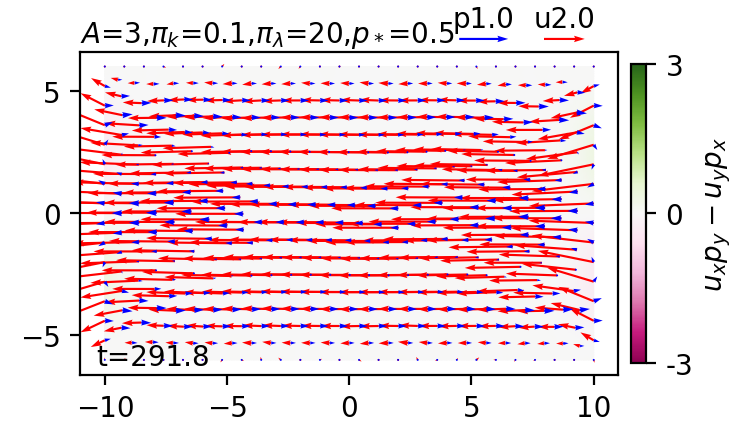

In [66]:
# show displacement and polarization vectors together 
importlib.reload(bio_mem_helpers) 

klist = [591,593,600,602,606,607]
if (1==1):# not a test
    root =  notebookroot+'_trycross'
    for k in klist:
        ofile = bio_mem_helpers.mkpngname(root,k)
        #print(ofile)
        time = timevec[k]
        tlabel = 't={:.1f}'.format(time)
        #pl = ''
        #if (k < 105):
        #pl = parmlabel
        bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_crossprod=True,\
            vecscale_u=1.2, vlength_set_u = 2, vecscale_p = 0.5,vlength_set_p = 1,yratio=0.7,cbar_shrink=0.6, \
                                    parmlabel=parmlabel,cbar_label=r'$u_x p_y - u_y p_x$',qkeyloc=1)
plt.close('all')

In [ ]:
# make a bunch of pngs from simulation output, movies!
root =  notebookroot+'_cross'
#coarsemesh = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh*2))  # maxh here sets the scale of elements 
for k in range(3, len(gfu_list)):
    ofile = bio_mem_helpers.mkpngname(root,k)
    time = timevec[k]
    time_label = 't={:.1f}'.format(time)
    pl = ''
    if (k < 50):
        pl = parmlabel
    bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,time_label,ofile,plt_crossprod=True,\
            vecscale_u=1.2, vlength_set_u = 2, vecscale_p = 0.5,vlength_set_p = 1,yratio=0.7,cbar_shrink=0.6, \
                                    parmlabel=pl,cbar_label=r'$u_x p_y - u_y p_x$',qkeyloc=1)
              
    if (k%10 == 0):
        plt.close('all')

In [ ]:
 # show displacement and polarization vectors together 
importlib.reload(bio_mem_helpers) 

klist = [300,310,593]
if (1==1):# not a test
    root =  notebookroot+'_trydisp'
    for k in klist:
        ofile = bio_mem_helpers.mkpngname(root,k)
        #print(ofile)
        time = timevec[k]
        tlabel = 't={:.1f}'.format(time)
        pl = ''
        if (k < 105):
            pl = parmlabel
        bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_dotprod=True,\
            vecscale_u=0.8, vlength_set_u = 2, vecscale_p = 0.5,vlength_set_p = 1,yratio=0.7,cbar_shrink=0.5, \
                                    parmlabel=pl,cbar_label=r'angle $\theta$',qkeyloc=1)


In [14]:
# show displacement and polarization vectors together 
importlib.reload(bio_mem_helpers) 

for k in range(3,len(gfu_list)):
    root =  notebookroot+'_trydisp'
    for k in klist:
        ofile = bio_mem_helpers.mkpngname(root,k)
        #print(ofile)
        time = timevec[k]
        tlabel = 't={:.1f}'.format(time)
        pl = ''
        if (k < 105):
            pl = parmlabel
        bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_dotprod=True,\
            vecscale_u=0.8, vlength_set_u = 2, vecscale_p = 0.5,vlength_set_p = 1,yratio=0.7,cbar_shrink=0.5, \
                                    parmlabel=pl,cbar_label=r'angle $\theta$',qkeyloc=1)


In [ ]:

if (1==1):# not a test
    #coarsemesh = ngsolve.Mesh(geo.GenerateMesh(maxh=maxh_mesh*2))  # maxh here sets the scale of elements 
    root =  notebookroot+'_disp'
    for k in range(3,len(timevec)):
    #for k in klist:
        ofile = bio_mem_helpers.mkpngname(root,k)
        time = timevec[k]
        tlabel = 't={:.1f}'.format(time)
        if (k <10):
            bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_dotprod=True,\
                vecscale_u=0.5, vlength_set_u = 2, vecscale_p = 0.2,vlength_set_p = 1,yratio=1,\
                        parmlabel=parmlabel,cbar_label=r'angle $\theta$')
                #cbar_label='$u \cdot p$'
        else:
            bio_mem_helpers.displot(gfu_list[k],gfp_list[k],mesh,coarsemesh,tlabel,ofile,plt_dotprod=True,\
                vecscale_u=0.5, vlength_set_u = 2, vecscale_p = 0.2,vlength_set_p = 1,yratio=1)
        if (k%10 == 0):
            plt.close('all')

In [41]:
import scipy
seed=3
rs = np.random.RandomState(seed)
x= scipy.stats.uniform.rvs(loc=0, scale=2, random_state=rs,size=(2,2))
print(x)

if (seed != None):
    self.rs = np.random.RandomState(seed)
else:
    self.rs = None

[[1.10159581 1.41629565]
 [0.58180948 1.02165521]]
